In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour
)

optuna.logging.set_verbosity(optuna.logging.INFO)
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
class AutoencoderDataset(Dataset):
    def __init__(self, data_tensor):
        self.data_tensor = data_tensor#.cuda()

    def __len__(self):
        return self.data_tensor.size(0)

    def __getitem__(self, idx):
        # For an autoencoder, X=Y (We need to reconstruct the input)
        x = self.data_tensor[idx]
        return x, x

In [3]:
# Charger les jeux d'entraînement et de test directement
train_df = pd.read_csv('../../../data/train_resample_minmax_all.csv')
val_df = pd.read_csv('../../../data/test_resample_minmax_all.csv')

# Print shapes
print("Train shape:", train_df.shape)
print("Test shape:", val_df.shape)

print(f"Total aggregate rows: {train_df.shape[0] + val_df.shape[0]}")


# Préparer tes données pour l'entraînement
data_id_train = train_df["apogee_id"]
data_target_train = train_df[["TEFF", "J", "H", "K", "LOGG"]]
train_data = train_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Préparer tes données pour la validation (test final)
data_id_val = val_df["apogee_id"]
data_target_val = val_df[["TEFF", "J", "H", "K", "LOGG"]]
val_data = val_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Convertir en tenseurs PyTorch directement
train_tensor = torch.tensor(train_data.values, dtype=torch.float32)
val_tensor = torch.tensor(val_data.values, dtype=torch.float32)




# Créer les datasets PyTorch correspondants
train_dataset = AutoencoderDataset(train_tensor)
val_dataset = AutoencoderDataset(val_tensor)

# Créer les DataLoaders correspondants
#train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4, persistent_workers=True)
#val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, num_workers=4, persistent_workers=True)
#train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, pin_memory=True, pin_memory_device="cuda:0")
#val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, pin_memory=True, pin_memory_device="cuda:0")

class DL():
    def __init__(self, ds, batch_size):
        self.ds = ds.cuda()
        self.batch_size = batch_size

    def __iter__(self):
        def inner():
            idx = torch.randperm(len(self.ds))
            for i in range(len(self.ds)//self.batch_size):
                b = self.ds[idx[i*self.batch_size:(i+1)*self.batch_size]]
                yield b, b

        return inner()

train_loader = DL(train_tensor,  batch_size=1024)
val_loader = DL(val_tensor, batch_size=1024)

# Optionnel : créer un tenseur global si nécessaire pour les visualisations plus tard :
full_data_tensor = torch.cat([train_tensor, val_tensor], dim=0)
data_id = pd.concat([data_id_train, data_id_val], ignore_index=True)





Train shape: (129124, 23)
Test shape: (32282, 23)
Total aggregate rows: 161406


In [4]:
class VAE(nn.Module):
    def __init__(
        self,
        input_dim=17,
        hidden_dim1=32,
        hidden_dim2=64,
        latent_dim=2,
        negative_slope=0.01,
    ):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(negative_slope=negative_slope),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(negative_slope=negative_slope),
        )
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(negative_slope=negative_slope),

            nn.Linear(hidden_dim2, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(negative_slope=negative_slope),

            nn.Linear(hidden_dim1, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


In [14]:

def vae_objective(trial):
    # --- Hyperparameters to tune ---
    latent_dim = trial.suggest_categorical("latent_dim", [2])
    hidden_dim1 = trial.suggest_int("hidden_dim1", 16, 128, step=16)
    hidden_dim2 = trial.suggest_int("hidden_dim2", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    negative_slope = trial.suggest_float("negative_slope", 1e-3, 1e-1, log=True)
    kl_weight = trial.suggest_float("kl_weight", 1e-4, 1.5, log=True)  

    # --- Build VAE ---
    model = VAE(
        input_dim=17,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=latent_dim,
        negative_slope=negative_slope
    ).to(device)

    # Torch compile (si désiré)
    model = torch.compile(model, mode="reduce-overhead")

    # Optimizer et fonction de reconstruction (MSE par ex.)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    recon_criterion = nn.MSELoss()

    # Hyperparamètres de training
    num_epochs = 200
    patience = 200
    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        # Phase d'entraînement
        model.train()
        train_loss = 0.0
        for X_batch, _ in train_loader:
            # X_batch = X_batch.to(device)
            optimizer.zero_grad()

            x_recon, mu, logvar = model(X_batch)
            recon_loss = recon_criterion(x_recon, X_batch)
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + kl_weight * kl_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(full_data_tensor)

        # Phase de validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, _ in val_loader:
                # X_batch = X_batch.to(device)
                x_recon, mu, logvar = model(X_batch)
                recon_loss = recon_criterion(x_recon, X_batch)
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + kl_weight * kl_loss
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_tensor)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

        # Optionnel: rapport à Optuna + pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_loss

In [15]:
def run_hyperparameter_search(n_trials=20):
    study = optuna.create_study(direction="minimize")
    study.optimize(vae_objective, n_trials=n_trials, show_progress_bar=True)

    print("Number of finished trials:", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial

    print(f"  Value (lowest val_loss): {best_trial.value}")
    print("  Params:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    return study

study = run_hyperparameter_search(n_trials=10)

[I 2025-03-29 09:55:08,101] A new study created in memory with name: no-name-e7854dc3-c80c-45d5-bd38-4d74071637aa


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-03-29 09:56:28,144] Trial 0 finished with value: 0.004510198898840095 and parameters: {'latent_dim': 2, 'hidden_dim1': 64, 'hidden_dim2': 16, 'lr': 8.069793149789271e-05, 'negative_slope': 0.001526730968463156, 'kl_weight': 0.5720167179001526}. Best is trial 0 with value: 0.004510198898840095.
[I 2025-03-29 09:57:43,515] Trial 1 finished with value: 0.004558468506051279 and parameters: {'latent_dim': 2, 'hidden_dim1': 64, 'hidden_dim2': 32, 'lr': 2.8178387758876776e-05, 'negative_slope': 0.04175053781728132, 'kl_weight': 0.012884749893665993}. Best is trial 0 with value: 0.004510198898840095.
[I 2025-03-29 09:59:01,232] Trial 2 finished with value: 0.004391629370487384 and parameters: {'latent_dim': 2, 'hidden_dim1': 96, 'hidden_dim2': 112, 'lr': 0.08921255327983983, 'negative_slope': 0.0037695129946982314, 'kl_weight': 0.007036063761854462}. Best is trial 2 with value: 0.004391629370487384.
[I 2025-03-29 10:00:17,099] Trial 3 finished with value: 0.0016749660422696949 and para

In [17]:
# Device et dossiers
print("Using device:", device)

output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)
weight_folder = "output_weight"
os.makedirs(weight_folder, exist_ok=True)

num_epochs = 1500
patience = 2000
regul_param = 0.05
dims = [2, 3, 4]

hidden_dim1= 96
hidden_dim2= 32
lr= 0.008560527077781604
negative_slope= 0.008943970479895846
kl_weight= 0.0003086732113971801
regul_param = kl_weight
# Boucle sur les dimensions latentes
for latent_dim in dims:
    print(f"\nTraining VAE with latent dimension: {latent_dim}")

    model = VAE(
        input_dim=17,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=latent_dim,
        negative_slope=negative_slope
    ).to(device)

    # Torch compile (si désiré)
    model = torch.compile(model, mode="reduce-overhead")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, _ in train_loader:
            X_batch = X_batch#.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(X_batch)
            recon_loss = criterion(x_recon, X_batch)
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + regul_param * kl_loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_tensor)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, _ in val_loader:
                X_batch = X_batch#.to(device)
                x_recon, mu, logvar = model(X_batch)
                recon_loss = criterion(x_recon, X_batch)
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + regul_param * kl_loss
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_tensor)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            model_file = os.path.join(weight_folder, f"best_vae_{latent_dim}D.pth")
            torch.save(model.state_dict(), model_file)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stop!")
                break

    # Charger le meilleur modèle
    model.load_state_dict(torch.load(model_file))
    model.eval()

    # Projection complète train+test pour visualisation finale
    with torch.no_grad():
        full_tensor_device = full_data_tensor.to(device)
        mu, _ = model.encode(full_tensor_device)
    latent_embeddings = mu.cpu().numpy()

    # Sauvegarde CSV claire
    df_latent = pd.DataFrame(latent_embeddings, columns=[f"latent_{i+1}" for i in range(latent_dim)])
    df_latent.insert(0, "apogee_id", data_id)

    output_file = os.path.join(output_folder, f"VAE_latent_space_{latent_dim}D.csv")
    df_latent.to_csv(output_file, index=False)
    print(f"Latent space {latent_dim}D saved to {output_file}")

Using device: cuda

Training VAE with latent dimension: 2
Epoch [1/1500]  Train Loss: 0.013631 | Val Loss: 0.002754
Epoch [2/1500]  Train Loss: 0.002502 | Val Loss: 0.002567
Epoch [3/1500]  Train Loss: 0.002350 | Val Loss: 0.002428
Epoch [4/1500]  Train Loss: 0.002254 | Val Loss: 0.002280
Epoch [5/1500]  Train Loss: 0.002190 | Val Loss: 0.002116
Epoch [6/1500]  Train Loss: 0.002177 | Val Loss: 0.002108
Epoch [7/1500]  Train Loss: 0.002125 | Val Loss: 0.002106
Epoch [8/1500]  Train Loss: 0.002098 | Val Loss: 0.002054
Epoch [9/1500]  Train Loss: 0.002027 | Val Loss: 0.002041
Epoch [10/1500]  Train Loss: 0.002057 | Val Loss: 0.002006
Epoch [11/1500]  Train Loss: 0.002054 | Val Loss: 0.001970
Epoch [12/1500]  Train Loss: 0.002055 | Val Loss: 0.001941
Epoch [13/1500]  Train Loss: 0.002033 | Val Loss: 0.002001
Epoch [14/1500]  Train Loss: 0.002020 | Val Loss: 0.001876
Epoch [15/1500]  Train Loss: 0.002008 | Val Loss: 0.001931
Epoch [16/1500]  Train Loss: 0.001992 | Val Loss: 0.001842
Epoch [

In [16]:
a = torch.ones(5).cuda()

print(a.device)

a *a

cuda:0


tensor([1., 1., 1., 1., 1.], device='cuda:0')

In [18]:

with torch.no_grad():
    full_data_gpu = full_data_tensor.to(device)
    mu, _ = model.encode(full_data_gpu)
    latent_2d = mu.cpu().numpy()


print("Lattend space shape :", latent_2d.shape)  # Devrait être (175809, 2)



Lattend space shape : (161406, 4)


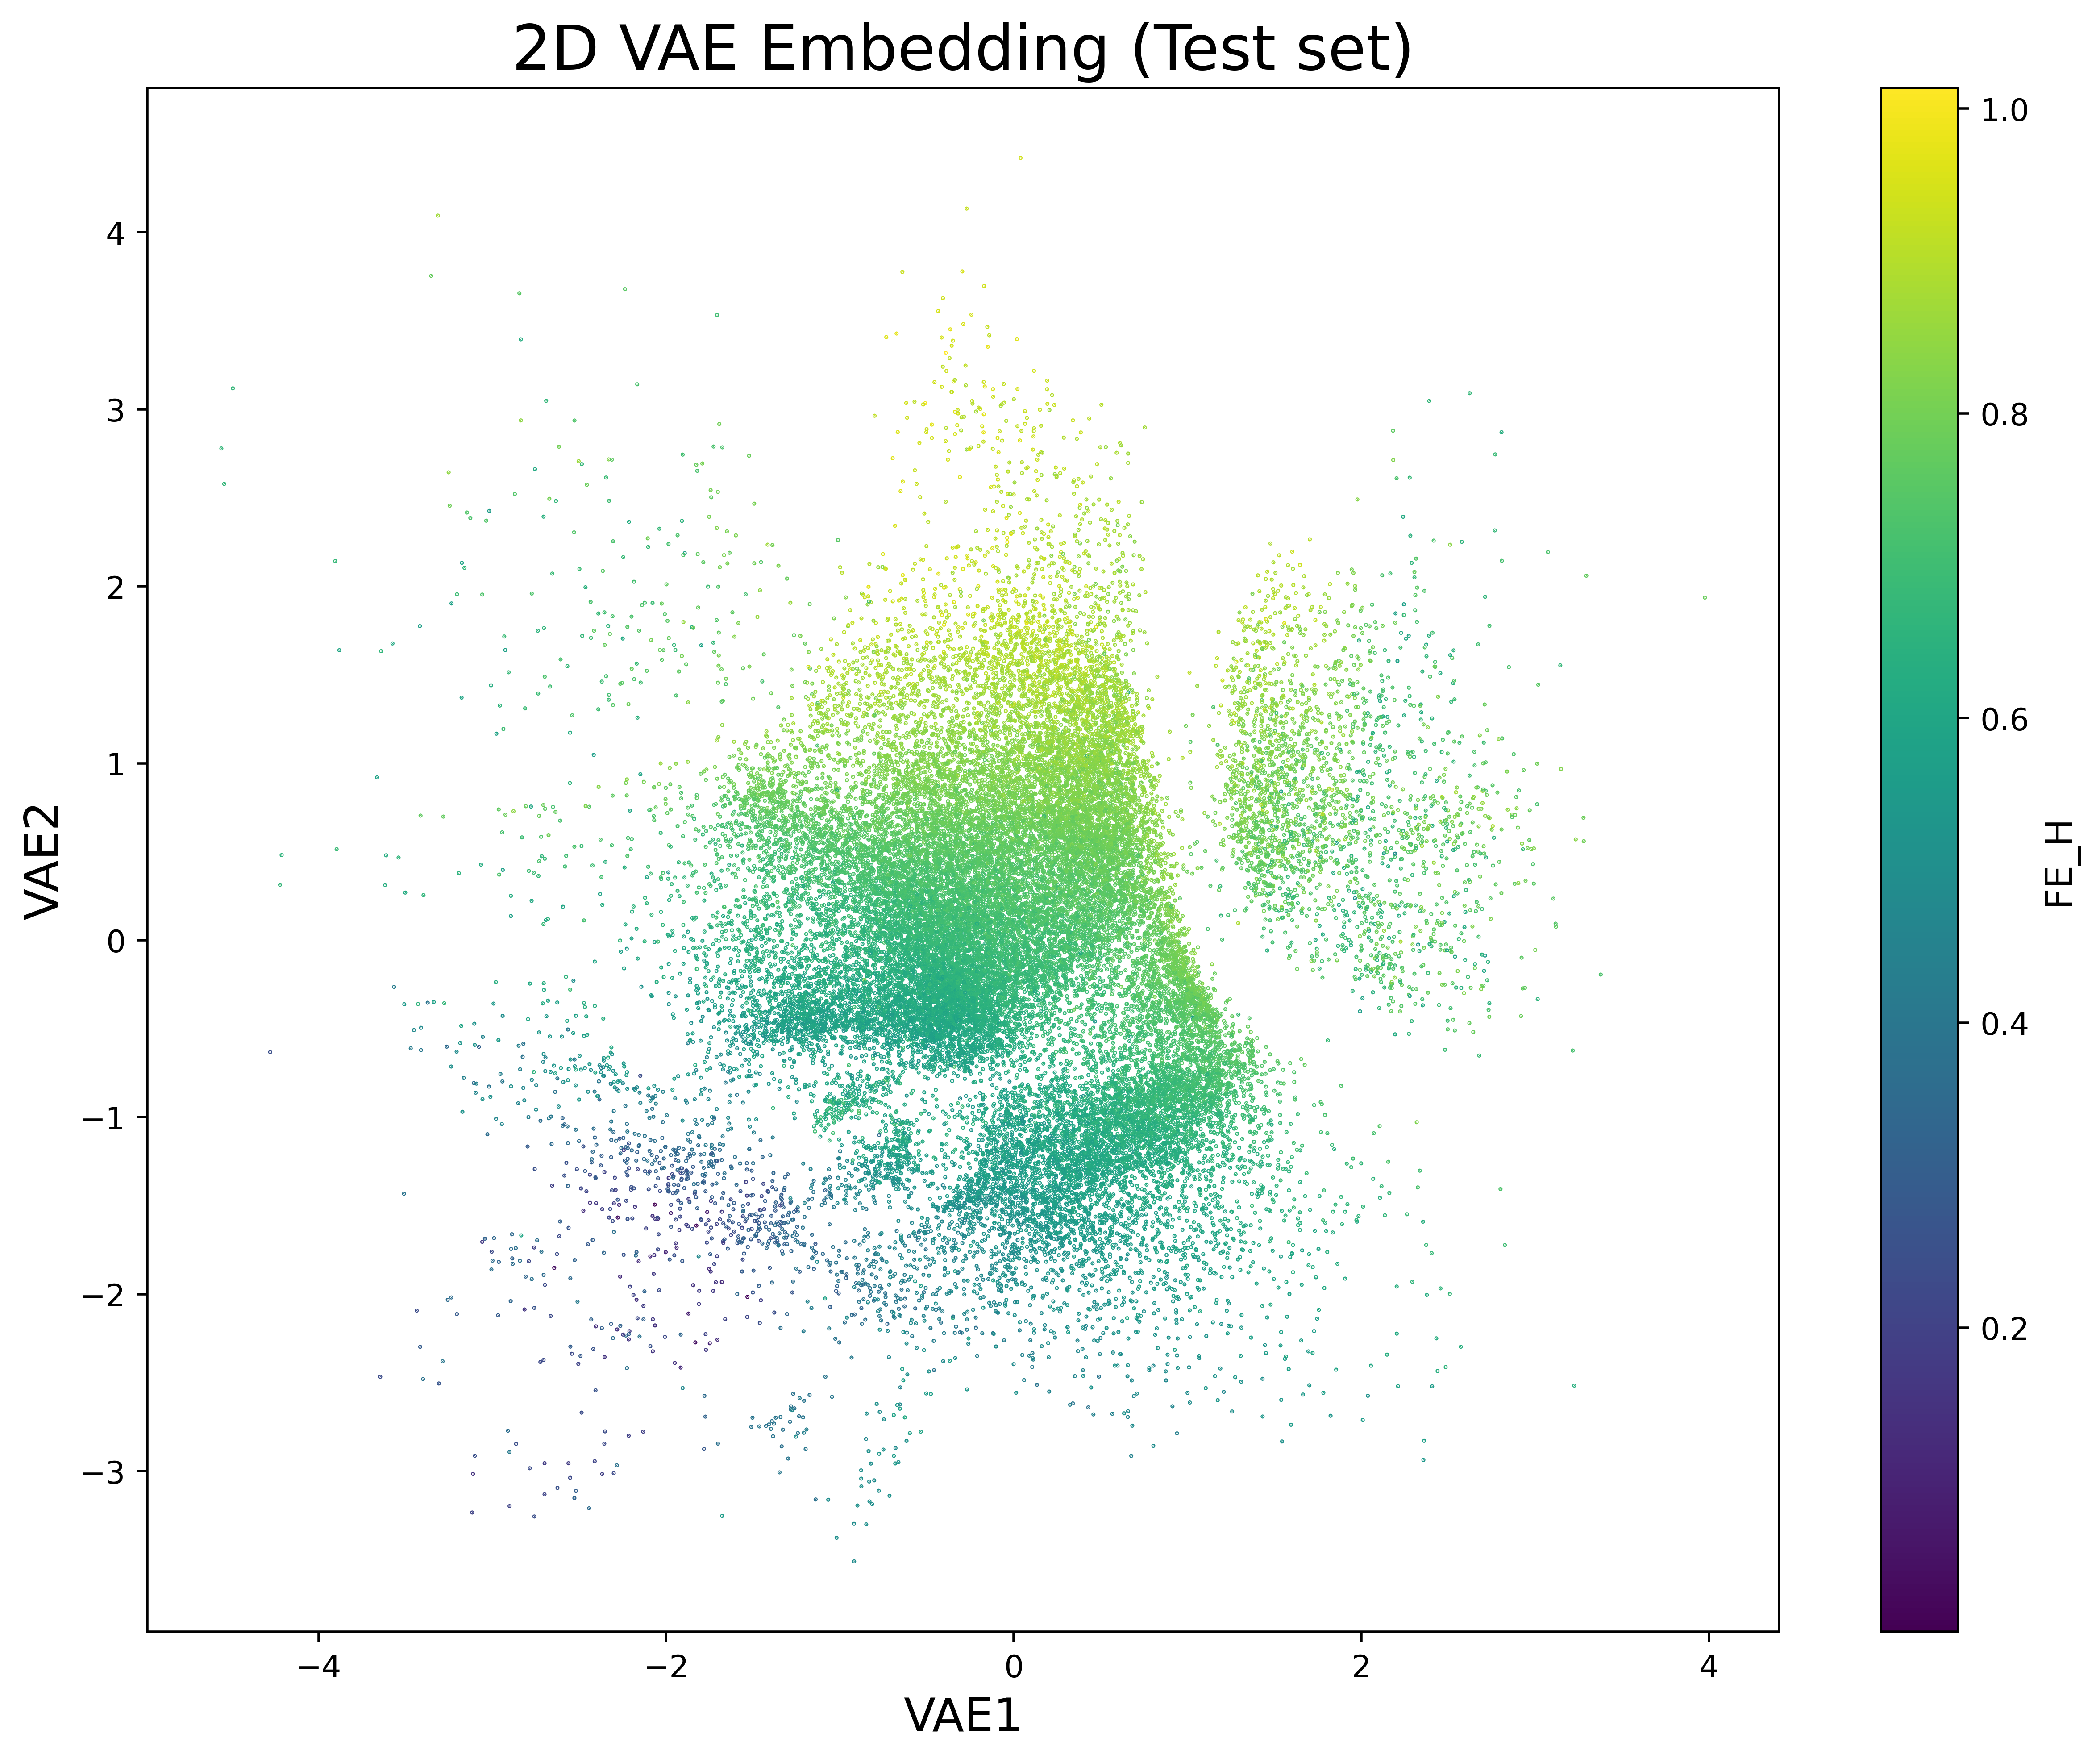

In [19]:
# Charger explicitement les embeddings depuis le CSV
data_to_plot = pd.read_csv("output_dataset/VAE_latent_space_2D.csv")


val_df_fe_h = val_df[['apogee_id', 'FE_H', 'TEFF']]
# get fe_h_values by merging with val_data
df_merged = pd.merge(data_to_plot, val_df_fe_h, on='apogee_id', how='inner')

# get latent_1 and latent_2 as numpy arrays
latent_1 = df_merged["latent_1"].values
latent_2 = df_merged["latent_2"].values
fe_h = df_merged["FE_H"].values

# Plot clair des embeddings avec FE_H comme couleur
fig = plt.figure(figsize=(10, 8), dpi=500)
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel('VAE1', fontsize=15)
ax.set_ylabel('VAE2', fontsize=15)
ax.set_title('2D VAE Embedding (Test set)', fontsize=20)

scatter = ax.scatter(
    latent_1,
    latent_2,
    cmap='viridis',
    c=fe_h,
    s=0.1
)

cbar = plt.colorbar(scatter)
cbar.set_label('FE_H', fontsize=12)

plt.tight_layout()
plt.show()

Étoile choisie (Test set): apogee_id=2M15425880-5522526, row_index=15


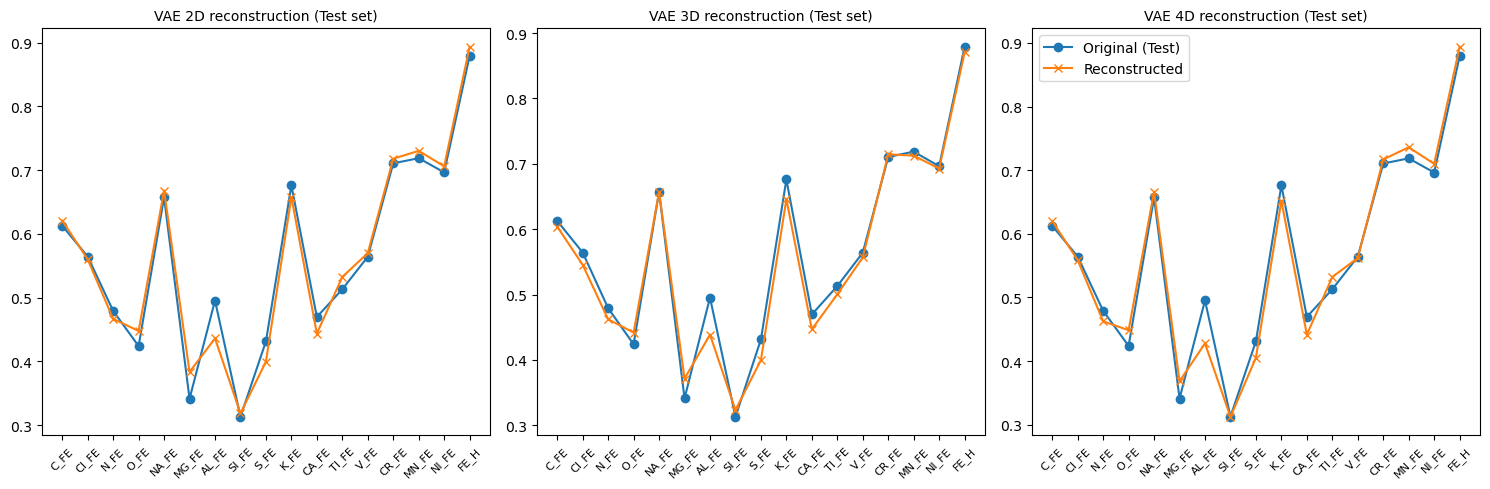

In [20]:
col_names = list(val_data.columns)  # colonnes numériques du test (sans apogee_id)

chosen_id = "2M15425880-5522526"
row_index = data_id_val[data_id_val == chosen_id].index
if len(row_index) == 0:
    raise ValueError(f"Impossible de trouver apogee_id='{chosen_id}' dans le jeu de TEST.")
row_index = row_index[0]
print(f"Étoile choisie (Test set): apogee_id={chosen_id}, row_index={row_index}")

original_abundance = val_data.iloc[row_index].values.astype(np.float32)

# Tenseur correspondant uniquement au jeu de test
x_star_tensor = val_tensor[row_index].unsqueeze(0).to(device)  # shape (1,17)

latent_dims = [2, 3, 4]
reconstructions = {}

for d in latent_dims:
    model =  VAE(
        input_dim=17,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=d,
        negative_slope=negative_slope
    ).to(device)
    
    model = torch.compile(model, mode="reduce-overhead")

    model_path = os.path.join(weight_folder, f"best_vae_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Avertissement: Fichier de poids introuvable: {model_path} ***")
        continue

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        x_recon, _, _ = model(x_star_tensor)
        x_recon = x_recon.cpu().numpy().flatten()

    reconstructions[d] = x_recon

fig, axes = plt.subplots(1, len(latent_dims), figsize=(5 * len(latent_dims), 5), dpi=100)

if len(latent_dims) == 1:
    axes = [axes]

for idx, d in enumerate(latent_dims):
    ax = axes[idx]
    if d not in reconstructions:
        ax.text(0.5, 0.5, f"{d}D\nNo model", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    recon = reconstructions[d]
    x = np.arange(len(col_names))

    ax.plot(x, original_abundance, marker='o', label="Original (Test)")
    ax.plot(x, recon, marker='x', label="Reconstructed")

    ax.set_xticks(x)
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    ax.set_title(f"VAE {d}D reconstruction (Test set)", fontsize=10)

    if idx == len(latent_dims) - 1:
        ax.legend()

plt.tight_layout()
plt.show()


N_test=32282, Variance totale=0.077706
VAE 2D: MSE=0.001135, Explained Var=0.985396
VAE 3D: MSE=0.000890, Explained Var=0.988551
VAE 4D: MSE=0.000734, Explained Var=0.990552


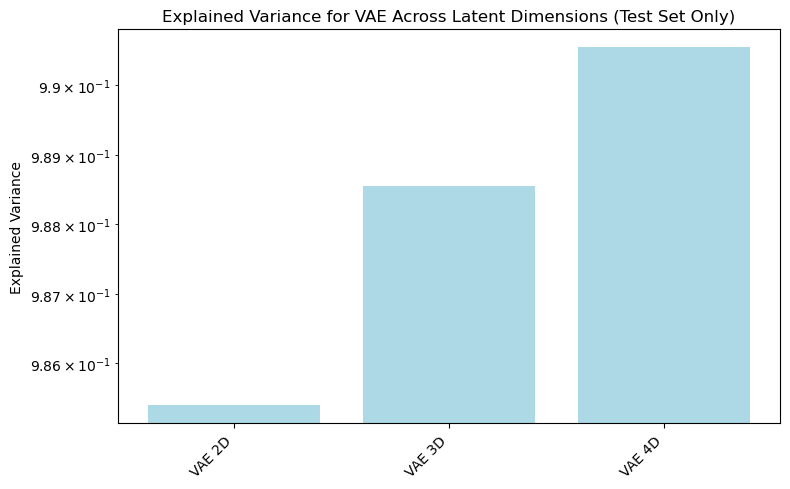

In [21]:
# Utiliser explicitement le jeu de TEST préparé précédemment
val_X_tensor = val_tensor  # déjà au format torch.FloatTensor, shape (N_val, 17)
val_X_np = val_X_tensor.cpu().numpy()

# Calcul précis de la covariance et variance totale uniquement sur le TEST
cov_matrix = np.cov(val_X_np, rowvar=False)
total_variance = np.trace(cov_matrix)
print(f"N_test={len(val_X_np)}, Variance totale={total_variance:.6f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_folder = "output_weight"

latent_dims = [2, 3, 4]
explained_variances_vae = {}

val_X_tensor = val_X_tensor.to(device)

for d in latent_dims:
    model_path = os.path.join(weight_folder, f"best_vae_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Pas de fichier pour {d}D: {model_path} ***")
        continue

    # Charger explicitement le modèle VAE entraîné
    model =  VAE(
        input_dim=17,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        latent_dim=d,
        negative_slope=negative_slope
    ).to(device)
    
    model = torch.compile(model, mode="reduce-overhead")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Reconstruction explicite uniquement sur le jeu TEST
    with torch.no_grad():
        x_recon_tensor, _, _ = model(val_X_tensor)
    x_recon_np = x_recon_tensor.cpu().numpy()

    # Calculer MSE global sur TEST
    mse_global = np.mean((x_recon_np - val_X_np)**2)

    # Calculer explicitement la variance expliquée sur TEST
    explained_variance = 1.0 - (mse_global / total_variance)
    explained_variances_vae[d] = explained_variance

    print(f"VAE {d}D: MSE={mse_global:.6f}, Explained Var={explained_variance:.6f}")

# ---------------------------------------------------
# Diagramme clair de la variance expliquée (TEST uniquement)
# ---------------------------------------------------
labels = [f"VAE {d}D" for d in latent_dims if d in explained_variances_vae]
ev_values = [explained_variances_vae[d] for d in latent_dims if d in explained_variances_vae]

plt.figure(figsize=(8, 5))
plt.bar(range(len(labels)), ev_values, color='lightblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.yscale("log")
plt.title("Explained Variance for VAE Across Latent Dimensions (Test Set Only)")
plt.tight_layout()
plt.show()
